# Bias-Variance Tradeoff — Why Models Fail and How to Fix Them

## The Central Tension in ML

Every model failure is either **bias** or **variance**. Knowing which one
tells you exactly what to do next.

| | Bias (Underfitting) | Variance (Overfitting) |
|---|---|---|
| **Symptom** | High train error AND high val error | Low train error, high val error |
| **Cause** | Model too simple | Model too complex |
| **Fix** | More features, more complex model | Regularization, more data, dropout |
| **Learning curve** | Both curves plateau high | Gap between train and val |

## The Decomposition

For any prediction error:

```
Total Error = Bias² + Variance + Irreducible Noise
```

- **Bias²** — systematic error from wrong assumptions (linear model on non-linear data)
- **Variance** — sensitivity to training data (memorizes training set)
- **Irreducible noise** — randomness in the data itself — no model can fix this

## What We Cover

| Section | Topic |
|---|---|
| 1 | Bias-variance decomposition — visual intuition |
| 2 | Learning curves — diagnosing from data |
| 3 | Evaluation for deep learning — train/val loss curves |
| 4 | Evaluation for LLMs — metrics beyond accuracy |


In [1]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.datasets import make_classification, make_regression
import seaborn as sns

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (confusion_matrix, precision_score, recall_score,
                              f1_score, roc_curve, auc, mean_squared_error,
                              mean_absolute_error, r2_score)
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

np.random.seed(42)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

---
## 7. Bias-Variance Tradeoff

Every model error decomposes into three parts:

$$\text{Error} = \underbrace{\text{Bias}^2}_{\text{underfitting}} + \underbrace{\text{Variance}}_{\text{overfitting}} + \underbrace{\text{Noise}}_{\text{irreducible}}$$

| | Bias | Variance | Symptom |
|---|---|---|---|
| **Too simple** | High | Low | Underfitting — bad on train AND test |
| **Too complex** | Low | High | Overfitting — great on train, bad on test |
| **Just right** | Moderate | Moderate | Good generalization |

**The fix:**
- High bias → more complex model, more features
- High variance → regularization, more data, simpler model

This is one of the most fundamental concepts in machine learning. It helps us diagnose our model's errors.

- **Bias**: The error from incorrect assumptions in the learning algorithm. High bias can cause the model to miss the relevant relations between features and target outputs (**underfitting**).
- **Variance**: The error from sensitivity to small fluctuations in the training set. High variance can cause the model to model the random noise in the training data, rather than the intended outputs (**overfitting**).

**The Goal**: Find a balance. A simple model has high bias and low variance. A complex model has low bias and high variance.

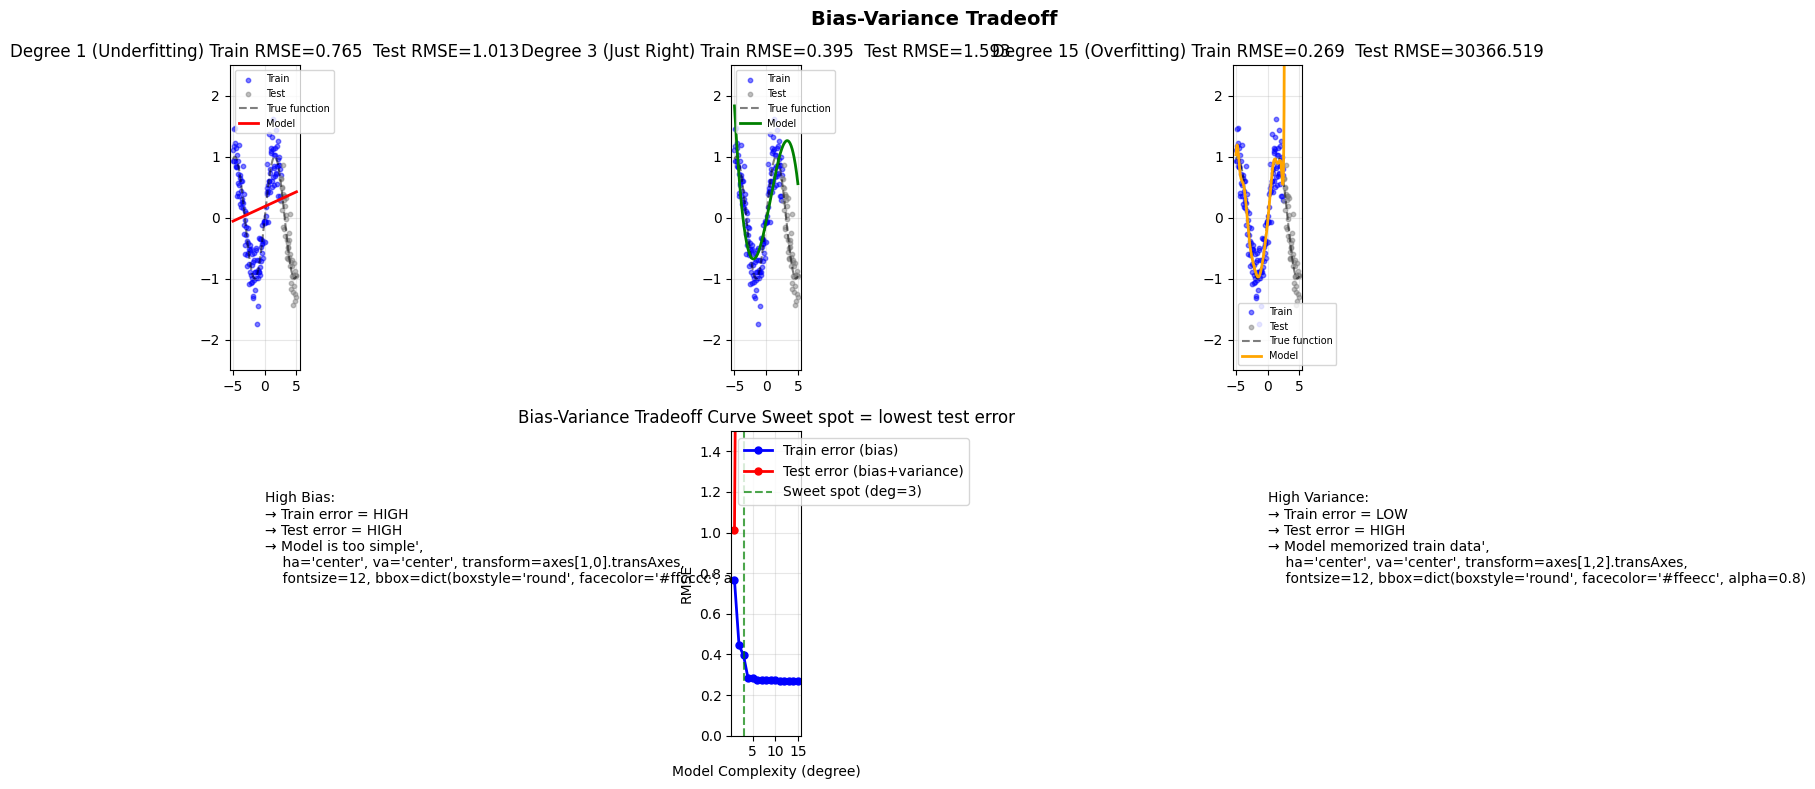

In [2]:
np.random.seed(42)
x_all = np.linspace(-5, 5, 200)
y_all = np.sin(x_all) + np.random.normal(0, 0.3, 200)

x_train, y_train = x_all[:150], y_all[:150]
x_test,  y_test  = x_all[150:], y_all[150:]

degrees = [1, 3, 15]
labels  = ['Degree 1 (Underfitting)', 'Degree 3 (Just Right)', 'Degree 15 (Overfitting)']
colors  = ['red', 'green', 'orange']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

train_errors, test_errors = [], []
for i, deg in enumerate(degrees):
    model = make_pipeline(PolynomialFeatures(deg), LinearRegression())
    model.fit(x_train.reshape(-1,1), y_train)
    y_pred_train = model.predict(x_train.reshape(-1,1))
    y_pred_test  = model.predict(x_test.reshape(-1,1))
    y_pred_all   = model.predict(x_all.reshape(-1,1))

    tr_err = np.sqrt(mean_squared_error(y_train, y_pred_train))
    te_err = np.sqrt(mean_squared_error(y_test,  y_pred_test))
    train_errors.append(tr_err)
    test_errors.append(te_err)

    axes[0, i].scatter(x_train, y_train, s=10, alpha=0.5, color='blue', label='Train')
    axes[0, i].scatter(x_test,  y_test,  s=10, alpha=0.5, color='gray', label='Test')
    axes[0, i].plot(x_all, np.sin(x_all), 'k--', lw=1.5, alpha=0.5, label='True function')
    axes[0, i].plot(x_all, y_pred_all, color=colors[i], lw=2, label='Model')
    axes[0, i].set_title(f'{labels[i]} Train RMSE={tr_err:.3f}  Test RMSE={te_err:.3f}')
    axes[0, i].set_ylim(-2.5, 2.5)
    axes[0, i].legend(fontsize=7)

# Bias-variance visualization
deg_range = range(1, 16)
tr_errs, te_errs = [], []
for d in deg_range:
    m = make_pipeline(PolynomialFeatures(d), LinearRegression())
    m.fit(x_train.reshape(-1,1), y_train)
    tr_errs.append(np.sqrt(mean_squared_error(y_train, m.predict(x_train.reshape(-1,1)))))
    te_errs.append(np.sqrt(mean_squared_error(y_test,  m.predict(x_test.reshape(-1,1)))))

ax = axes[1, 1]
ax.plot(deg_range, tr_errs, 'b-o', ms=5, lw=2, label='Train error (bias)')
ax.plot(deg_range, te_errs, 'r-o', ms=5, lw=2, label='Test error (bias+variance)')
ax.axvline(3, color='green', linestyle='--', alpha=0.7, label='Sweet spot (deg=3)')
ax.set_xlabel('Model Complexity (degree)')
ax.set_ylabel('RMSE')
ax.set_title('Bias-Variance Tradeoff Curve Sweet spot = lowest test error')
ax.set_ylim(0, 1.5)
ax.legend()

axes[1, 0].text(0.5, 0.5,
"""High Bias:
→ Train error = HIGH
→ Test error = HIGH
→ Model is too simple',
    ha='center', va='center', transform=axes[1,0].transAxes,
    fontsize=12, bbox=dict(boxstyle='round', facecolor='#ffcccc', alpha=0.8)""")
axes[1, 0].axis('off')

axes[1, 2].text(0.5, 0.5,
"""High Variance:
→ Train error = LOW
→ Test error = HIGH
→ Model memorized train data',
    ha='center', va='center', transform=axes[1,2].transAxes,
    fontsize=12, bbox=dict(boxstyle='round', facecolor='#ffeecc', alpha=0.8)""")
axes[1, 2].axis('off')

plt.suptitle('Bias-Variance Tradeoff', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

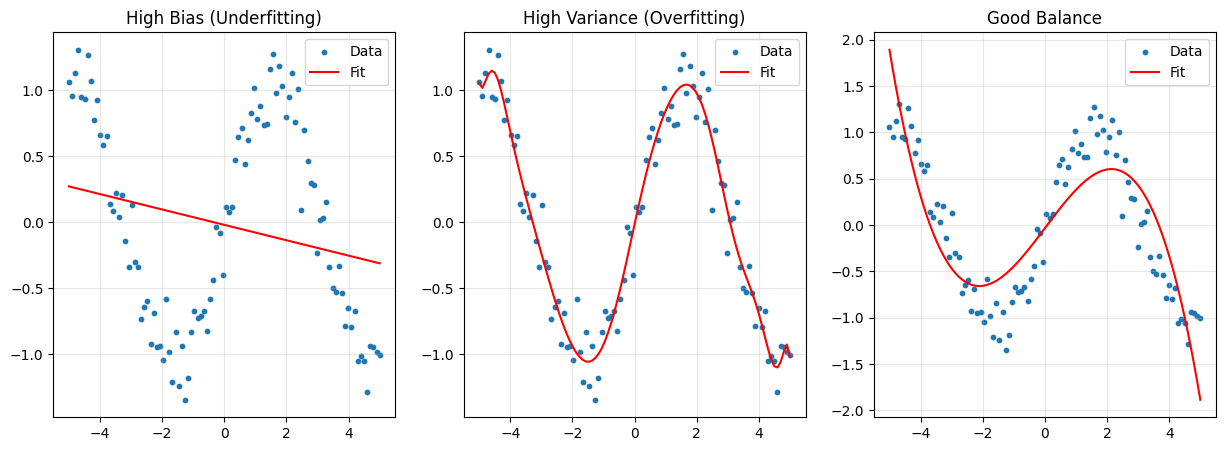

In [3]:
# Let's create a synthetic dataset with a non-linear relationship
np.random.seed(42)
x = np.linspace(-5, 5, 100)
y_true = np.sin(x) + np.random.normal(0, 0.2, 100)

# --- Model 1: Low Complexity (High Bias, Low Variance) ---
# This is a simple linear model (degree 1 polynomial)
p1 = np.polyfit(x, y_true, 1)
y_pred1 = np.polyval(p1, x)

# --- Model 2: High Complexity (Low Bias, High Variance) ---
# This is a very complex model (degree 15 polynomial)
p15 = np.polyfit(x, y_true, 15)
y_pred15 = np.polyval(p15, x)

# --- Model 3: 'Just Right' ---
# This model's complexity is close to the true function
p3 = np.polyfit(x, y_true, 3)
y_pred3 = np.polyval(p3, x)

# --- Visualization ---
plt.figure(figsize=(15, 5))

# Underfitting
plt.subplot(1, 3, 1)
plt.scatter(x, y_true, s=10, label='Data')
plt.plot(x, y_pred1, color='red', label='Fit')
plt.title('High Bias (Underfitting)')
plt.legend()

# Overfitting
plt.subplot(1, 3, 2)
plt.scatter(x, y_true, s=10, label='Data')
plt.plot(x, y_pred15, color='red', label='Fit')
plt.title('High Variance (Overfitting)')
plt.legend()

# Good Fit
plt.subplot(1, 3, 3)
plt.scatter(x, y_true, s=10, label='Data')
plt.plot(x, y_pred3, color='red', label='Fit')
plt.title('Good Balance')
plt.legend()

plt.show()

---
## 8. Learning Curves

A **learning curve** plots model performance vs training set size.  
It tells you: **is the problem data or model?**

| Pattern | Diagnosis | Fix |
|---|---|---|
| Train and test both high error | High bias (underfitting) | More complex model |
| Large gap between train and test | High variance (overfitting) | More data OR regularize |
| Both errors low, small gap | Good generalization | Ship it |
| Test error plateaued | More data won't help | Change model |

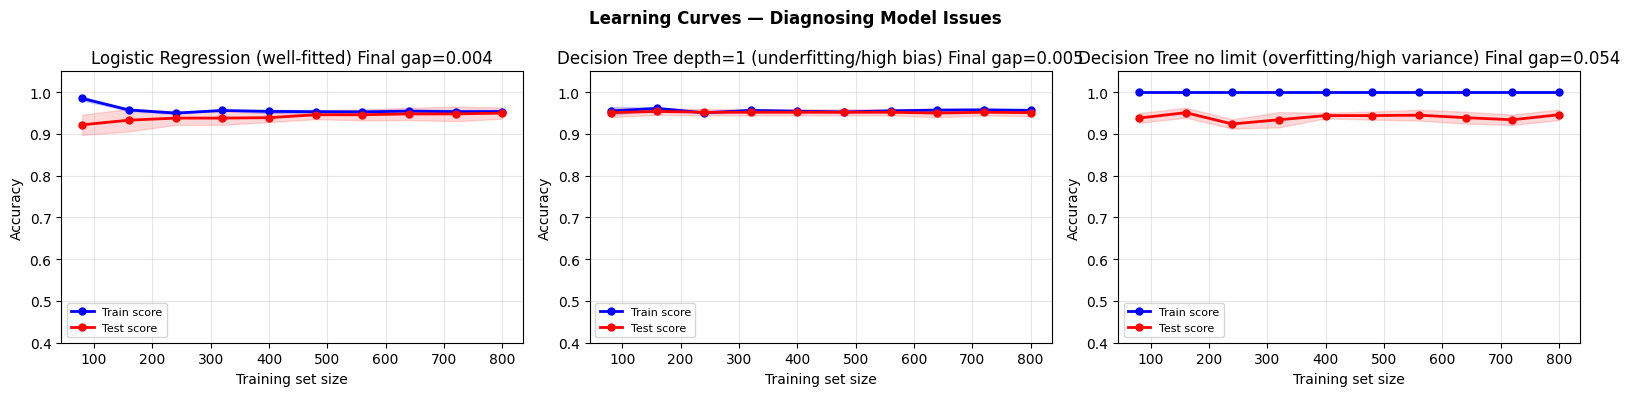

Reading learning curves:
  Blue (train) high, Red (test) high → underfitting, add complexity
  Blue high, Red low, BIG gap        → overfitting, regularize or get more data
  Both curves plateau                → getting more data won't help


In [4]:
from sklearn.datasets import make_classification
from sklearn.model_selection import learning_curve

X, y = make_classification(n_samples=1000, n_features=10, random_state=0)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

configs = [
    (LogisticRegression(max_iter=1000),'Logistic Regression (well-fitted)'),
    (DecisionTreeClassifier(max_depth=1),'Decision Tree depth=1 (underfitting/high bias)'),
    (DecisionTreeClassifier(max_depth=None),'Decision Tree no limit (overfitting/high variance)'),
]

for ax, (model, title) in zip(axes, configs):
    train_sizes, train_scores, test_scores, fit_times, score_times = learning_curve(
          model,
          X,
          y,
          cv=5,
          n_jobs=-1,
          train_sizes=np.linspace(0.1, 1.0, 10),
          scoring='accuracy',
          return_times=True
        )

    tr_mean = train_scores.mean(axis=1)
    tr_std  = train_scores.std(axis=1)
    te_mean = test_scores.mean(axis=1)
    te_std  = test_scores.std(axis=1)

    ax.fill_between(train_sizes, tr_mean-tr_std, tr_mean+tr_std, alpha=0.15, color='blue')
    ax.fill_between(train_sizes, te_mean-te_std, te_mean+te_std, alpha=0.15, color='red')
    ax.plot(train_sizes, tr_mean, 'b-o', ms=5, lw=2, label='Train score')
    ax.plot(train_sizes, te_mean, 'r-o', ms=5, lw=2, label='Test score')

    gap = tr_mean[-1] - te_mean[-1]
    ax.set_title(f'{title} Final gap={gap:.3f}')
    ax.set_xlabel('Training set size')
    ax.set_ylabel('Accuracy')
    ax.set_ylim(0.4, 1.05)
    ax.legend(fontsize=8)

plt.suptitle('Learning Curves — Diagnosing Model Issues', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print("Reading learning curves:")
print("  Blue (train) high, Red (test) high → underfitting, add complexity")
print("  Blue high, Red low, BIG gap        → overfitting, regularize or get more data")
print("  Both curves plateau                → getting more data won't help")


---
## 9. Evaluation for Deep Learning

Deep learning has extra evaluation concerns beyond accuracy metrics.

### Train / Validation / Test Split
```
All data
  ├── Train set (70-80%)      → model learns from this
  ├── Validation set (10-15%) → tune hyperparameters, stop early
  └── Test set (10-15%)       → final unbiased evaluation (use ONCE)
```

### Early Stopping
Monitor validation loss. Stop when it starts increasing — the model has started overfitting.

### Key DL-specific pitfalls:
- **Data leakage** — test data accidentally influencing training
- **Overfit to validation** — tuning too many hyperparameters on validation set
- **Using test set multiple times** — inflates reported performance

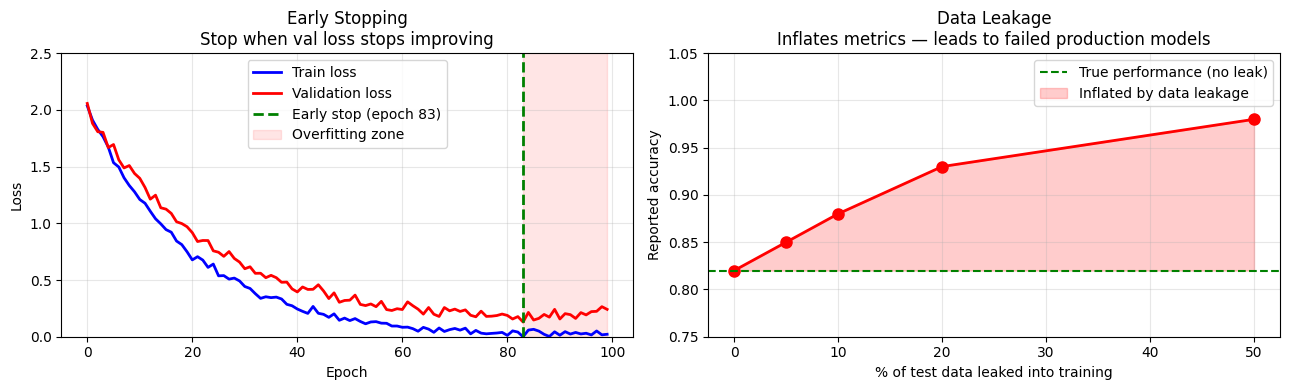

Early stopping best epoch: 83
Using model from epoch 83 prevents overfitting

DL evaluation checklist:
  ✓ Separate train / val / test (never mix)
  ✓ Use val set for hyperparameter tuning
  ✓ Use test set ONCE at the very end
  ✓ Check for data leakage (temporal splits, etc.)
  ✓ Report mean ± std across multiple seeds


In [5]:
# Simulate training curves with early stopping
np.random.seed(0)
epochs = 100

# Generate realistic loss curves
train_loss = 2.0 * np.exp(-epochs * np.linspace(0, 1, epochs) * 0.05)
train_loss += np.random.normal(0, 0.02, epochs)

# Val loss: decreases then increases (overfitting)
val_loss = 2.0 * np.exp(-epochs * np.linspace(0, 1, epochs) * 0.04)
val_loss += np.linspace(0, 0.3, epochs) ** 1.5  # overfitting component
val_loss += np.random.normal(0, 0.03, epochs)

best_epoch = np.argmin(val_loss)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(train_loss, 'b-', lw=2, label='Train loss')
axes[0].plot(val_loss, 'r-', lw=2, label='Validation loss')
axes[0].axvline(best_epoch, color='green', linestyle='--', lw=2,
                label=f'Early stop (epoch {best_epoch})')
axes[0].fill_between(range(best_epoch, epochs), 0, 3, alpha=0.1, color='red',
                    label='Overfitting zone')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Early Stopping\nStop when val loss stops improving')
axes[0].set_ylim(0, 2.5)
axes[0].legend()

# Data leakage example
leak_sizes = [0, 5, 10, 20, 50]  # % of test data leaked into training
leaked_acc = [0.82, 0.85, 0.88, 0.93, 0.98]  # inflated accuracy

axes[1].plot(leak_sizes, leaked_acc, 'r-o', lw=2, ms=8)
axes[1].axhline(0.82, color='green', linestyle='--', label='True performance (no leak)')
axes[1].fill_between(leak_sizes, 0.82, leaked_acc, alpha=0.2, color='red',
                    label='Inflated by data leakage')
axes[1].set_xlabel('% of test data leaked into training')
axes[1].set_ylabel('Reported accuracy')
axes[1].set_title('Data Leakage\nInflates metrics — leads to failed production models')
axes[1].legend()
axes[1].set_ylim(0.75, 1.05)

plt.tight_layout()
plt.show()

print("Early stopping best epoch:", best_epoch)
print("Using model from epoch", best_epoch, "prevents overfitting")
print()
print("DL evaluation checklist:")
print("  ✓ Separate train / val / test (never mix)")
print("  ✓ Use val set for hyperparameter tuning")
print("  ✓ Use test set ONCE at the very end")
print("  ✓ Check for data leakage (temporal splits, etc.)")
print("  ✓ Report mean ± std across multiple seeds")

---
## 10. Evaluation for LLMs & Generative AI

Evaluating generative models is fundamentally harder — there's no single right answer.

| Metric | What it measures | Used for |
|---|---|---|
| **Perplexity** | How well model predicts text | Language model quality |
| **BLEU** | N-gram overlap with reference | Machine translation |
| **ROUGE** | Recall-based overlap | Summarization |
| **FID** | Feature distribution similarity | Image generation |
| **Win rate** | Human preference A vs B | LLM alignment (RLHF) |
| **MMLU** | Knowledge benchmark | General capability |

> **The hard truth:** All automated metrics are imperfect proxies.  
> Human evaluation is the gold standard for LLM quality — but it's expensive.

=== BLEU Score (text generation quality) ===
Reference: 'The cat sat on the mat near the window'

  Good translation      : BLEU=0.667  'The cat sat on the mat'
  OK translation        : BLEU=0.333  'A cat was sitting on a mat'
  Bad translation       : BLEU=0.222  'The dog ran in the park yesterday'
  Degenerate            : BLEU=0.333  'the the the the the the the the'
 === Perplexity ===
  GPT-4 on common text               : PPL =      1.3
  GPT-4 on rare text                 : PPL =      3.3
  Small model                        : PPL =      8.1
  Random baseline (1/50k)            : PPL =  49999.8


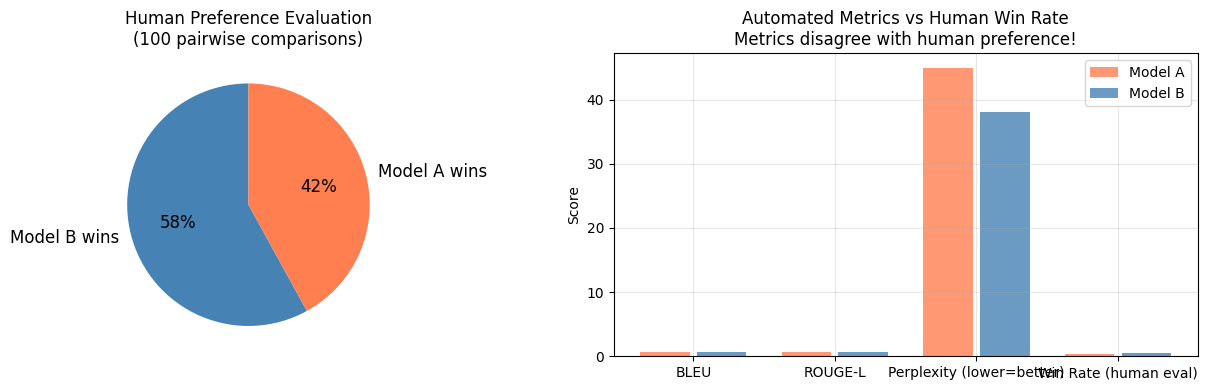


Key lesson: BLEU and ROUGE favor Model A, but humans prefer Model B.
Automated metrics are imperfect. Human evaluation is the ground truth.


In [6]:
from collections import Counter

# BLEU score — measures translation/generation quality
def bleu_1gram(reference, hypothesis):
    # Simplified unigram BLEU
    ref_tokens = reference.lower().split()
    hyp_tokens = hypothesis.lower().split()
    ref_counts = Counter(ref_tokens)
    matches = sum(min(hyp_tokens.count(w), ref_counts[w]) for w in set(hyp_tokens))
    precision = matches / len(hyp_tokens) if hyp_tokens else 0
    # Brevity penalty
    bp = min(1.0, len(hyp_tokens) / len(ref_tokens)) if ref_tokens else 0
    return bp * precision

reference  = "The cat sat on the mat near the window"
hyp_good   = "The cat sat on the mat"
hyp_ok     = "A cat was sitting on a mat"
hyp_bad    = "The dog ran in the park yesterday"
hyp_repeat = "the the the the the the the the"

print("=== BLEU Score (text generation quality) ===")
print(f"Reference: '{reference}'")
print()
for hyp, name in [(hyp_good,'Good translation'),(hyp_ok,'OK translation'),
                  (hyp_bad,'Bad translation'),(hyp_repeat,'Degenerate')]:
    score = bleu_1gram(reference, hyp)
    print(f"  {name:22}: BLEU={score:.3f}  '{hyp}'")

# Perplexity comparison
def perplexity_from_probs(token_probs):
    return np.exp(-np.mean(np.log(np.array(token_probs) + 1e-10)))

print(" === Perplexity ===")
scenarios = [
    ("GPT-4 on common text",    [0.7, 0.8, 0.6, 0.9, 0.75]),
    ("GPT-4 on rare text",      [0.3, 0.4, 0.2, 0.35, 0.3]),
    ("Small model",             [0.1, 0.15, 0.08, 0.2, 0.12]),
    ("Random baseline (1/50k)", [1/50000]*5),
]
for name, probs in scenarios:
    ppl = perplexity_from_probs(probs)
    print(f"  {name:35}: PPL = {ppl:8.1f}")

# Win rate simulation (human preference evaluation)
np.random.seed(1)
n_comparisons = 100
model_a_wins = 42  # out of 100 comparisons
model_b_wins = 58
ties = 0

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

labels_pie = ['Model B wins', 'Model A wins']
sizes = [model_b_wins, model_a_wins]
colors_pie = ['steelblue', 'coral']
axes[0].pie(sizes, labels=labels_pie, colors=colors_pie, autopct='%1.0f%%',
            startangle=90, textprops={'fontsize':12})
axes[0].set_title(f'Human Preference Evaluation\n({n_comparisons} pairwise comparisons)')

metrics = ['BLEU', 'ROUGE-L', 'Perplexity (lower=better)', 'Win Rate (human eval)']
model_a = [0.72, 0.68, 45, 0.42]
model_b = [0.69, 0.71, 38, 0.58]
x = np.arange(len(metrics))
axes[1].bar(x-0.2, model_a, 0.35, label='Model A', color='coral', alpha=0.8)
axes[1].bar(x+0.2, model_b, 0.35, label='Model B', color='steelblue', alpha=0.8)
axes[1].set_xticks(x)
axes[1].set_xticklabels(metrics)
axes[1].set_title('Automated Metrics vs Human Win Rate\nMetrics disagree with human preference!')
axes[1].legend()
axes[1].set_ylabel('Score')

plt.tight_layout()
plt.show()
print("\nKey lesson: BLEU and ROUGE favor Model A, but humans prefer Model B.")
print("Automated metrics are imperfect. Human evaluation is the ground truth.")

---
## Summary — Evaluation Across the Stack

```
Classic ML
  └── Confusion matrix           → Where are the errors?
  └── Precision / Recall         → Imbalanced classes
  └── AUC-ROC                    → Threshold-independent classifier ranking
  └── RMSE / R²                  → Regression quality
  └── Cross-validation           → Reliable generalization estimate
  └── Bias-variance tradeoff     → Diagnose under/overfitting
  └── Learning curves            → Is more data the answer?

Deep Learning
  └── Train/val/test split       → Never contaminate test set
  └── Early stopping             → Stop when val loss plateaus
  └── Data leakage detection     → Most common cause of inflated metrics

LLMs & Generative AI
  └── Perplexity                 → Text prediction quality
  └── BLEU / ROUGE               → Translation / summarization overlap
  └── FID                        → Image generation quality
  └── Win rate (human eval)      → Ground truth — but expensive
```

| Metric | Use when | Never use when |
|---|---|---|
| Accuracy | Classes balanced | Imbalanced dataset |
| F1 | Imbalanced, both P and R matter | Regression |
| AUC-ROC | Comparing classifiers overall | Comparing at a specific threshold |
| RMSE | Penalize large errors | Outliers are unavoidable |
| MAE | Outliers expected | Need to penalize large errors |
| Cross-val | Always, for final evaluation | Exploratory/quick checks |
| Perplexity | Language model quality | Image or structured generation |
| BLEU/ROUGE | Translation/summarization | Open-ended generation |
| Human eval | LLM quality | When scale or budget prohibit it |

### What to learn next
- **regression.ipynb** → apply these metrics on your first Kaggle dataset
- **decision_trees.ipynb** → see bias-variance tradeoff with tree depth
- **model_selection.ipynb** → grid search, hyperparameter tuning

---
## Summary — Bias, Variance & Learning Curves

### The Diagnostic Flowchart

```
Train a model and measure train_score and val_score
                    |
        ┌───────────┴───────────┐
   Both scores low         Train high, val low
   (underfitting/bias)     (overfitting/variance)
        |                       |
   Add features            Regularize (Ridge, Dropout)
   More complex model       More training data
   Remove regularization    Feature selection
   Longer training          Early stopping
                            Cross-validation
```

### Learning Curve Patterns

```python
from sklearn.model_selection import learning_curve

train_sz, train_sc, val_sc = learning_curve(
    model, X, y,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=5, scoring='r2', n_jobs=-1
)

# Plot mean +/- std
plt.plot(train_sz, train_sc.mean(axis=1), label='train')
plt.plot(train_sz, val_sc.mean(axis=1),   label='val')
```

**High bias:** both curves converge to a low score — adding data won't help
**High variance:** large gap between curves — more data or regularization helps

### Deep Learning Specific

```python
# After each epoch, log both:
history = {'train_loss': [], 'val_loss': []}

# Overfitting signal:
# val_loss starts increasing while train_loss keeps decreasing

# Fix: EarlyStopping(patience=5, restore_best_weights=True)
```

### LLM / Generative AI Metrics

| Task | Metric |
|---|---|
| Text generation | Perplexity (lower = better language model) |
| Translation / summarization | BLEU, ROUGE |
| Semantic similarity | BERTScore |
| RAG / QA | Faithfulness, Answer Relevancy |
| Human preference | Win rate vs baseline |

### The Three-Notebook Summary

| Notebook | Core Question |
|---|---|
| `metrics.ipynb` | *What* to measure |
| `cross_validation.ipynb` | *How reliably* to measure it |
| `bias_variance_tradeoff.ipynb` | *Why* it's wrong and how to fix it |
